In [1]:
from rugby_ranking.notebook_utils import setup_notebook_environment, load_model_and_trace
from rugby_ranking.model.predictions import MatchPredictor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
# Setup
dataset, df, model_dir = setup_notebook_environment()

Loading from: /home/daniel/repositories/personal/Rugby-Data
Loaded 14609 matches from /home/daniel/repositories/personal/Rugby-Data/json
Found 12367 unique players
Found 235 unique teams
✓ Loaded 434,150 player-match observations
  Players: 12,362
  Teams: 143
  Matches: 19,291
  Date range: 2006-09-02 to 2026-02-27

Data Quality Checks:
✓ Removed 1358 conversions and 451 penalties
  from 1016 player-match records in non-kicking positions
  Affected players: 439


In [2]:
model, trace = load_model_and_trace("international-mini5")

ℹ  Loading checkpoint: international-mini5
Loaded checkpoint from /home/daniel/.cache/rugby_ranking/international-mini5
✓ Loaded successfully
ℹ    Players: 7,127
ℹ    Team-seasons: 428


In [3]:
colors = { "England":"#C8102E", "France":"#002395", "Ireland":"#009A44", "Italy":"#0066CC",   "Scotland":"#003F8F", "Wales":"#D62B2F" };

In [4]:
predictor = MatchPredictor(model, trace)

In [5]:
predictions = predictor.predict_teams_only("England", "Ireland", "2026-2027")

In [6]:
plt.style.use(["~/.config/matplotlib/stylelib/kentigern-light.mplstyle",
               "~/.config/matplotlib/stylelib/kentigern-map.mplstyle"])

In [7]:
def plot_2d_predictions(predictions, truth=None, show_hist=False, median=True):
    f, ax = plt.subplots(1,1)

    bins = np.arange(0, 100, 1)
    X, Y = np.meshgrid(bins, bins)  

    if show_hist:
        ax.hist2d(predictions.home.samples, predictions.away.samples, bins=bins, cmap="Blues", alpha=0.5)
    estimator = stats.gaussian_kde(
        np.vstack([predictions.home.samples, predictions.away.samples])
    )
    Z = estimator(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    ax.set_xlim(0,50)
    ax.set_ylim(0,50)
    
    probs = [0.393, 0.865, 0.989]

    z_sorted = np.sort(Z.ravel())[::-1]
    cdf = np.cumsum(z_sorted)
    cdf /= cdf[-1]
    levels = [z_sorted[np.searchsorted(cdf, p)] for p in probs]
    levels = np.sort(levels)

    ax.matshow(Z, extent=(0, 100, 0, 100), origin='lower', cmap="inferno", alpha=0.7)

    cs = ax.contour(X, Y, Z, levels=levels, colors=["white"])
    
    ax.clabel(cs, fmt={levels[0]: '3σ', levels[1]: '2σ', levels[2]: '1σ'}, inline=True)
    ax.set_xlabel(f"{predictions.home.team} points")
    ax.set_ylabel(f"{predictions.away.team} points")

    if truth:
        ax.hlines(truth[1], 0, 50, )
        ax.vlines(truth[0], 0, 50, )

    if median:
        ax.scatter(np.median(predictions.home.samples), np.median(predictions.away.samples), color="black", marker="X", s=100, label="Median")

    return f

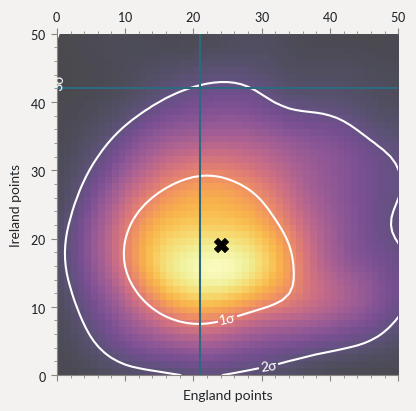

In [8]:
with plt.style.context("~/.config/matplotlib/stylelib/kentigern-light.mplstyle"):
    f = plot_2d_predictions(predictions, truth=(21, 42))
    f.savefig("six-nations-week-2-eng-ire.png", dpi=300)

In [9]:
predictions = predictor.predict_teams_only("Wales", "Scotland", "2026-2027")
f = plot_2d_predictions(predictions, truth=(23, 26))
f.savefig("six-nations-week-2-wal-sco.png", dpi=300)

In [10]:
predictions = predictor.predict_teams_only("France", "Italy", "2026-2027")
plot_2d_predictions(predictions, truth=(33, 8))
f.savefig("six-nations-week-2-fra-ita.png", dpi=300)

In [11]:
# Build match-level dataframe for form and H2H analysis
INTERNATIONAL_COMPS = ['six-nations', 'mid-year-internationals',
                       'end-of-year-internationals', 'world-cup']

match_df = (
    df[df['competition'].isin(INTERNATIONAL_COMPS)]
    .drop_duplicates(subset=['team', 'date', 'opponent'])
    .copy()
)
match_df['date'] = pd.to_datetime(match_df['date'])
match_df['margin'] = match_df['team_score'] - match_df['opponent_score']
print(f'International match records: {len(match_df)}')

International match records: 664


In [12]:
RESULT_COLORS = {'win': '#2ecc71', 'loss': '#e74c3c', 'draw': '#f39c12'}

def plot_recent_form(team, n=8, ax=None):
    """Horizontal strip showing last n test match results."""
    team_matches = (
        match_df[match_df['team'] == team]
        .sort_values('date')
        .tail(n)
    )
    if ax is None:
        f, ax = plt.subplots(1, 1, figsize=(10, 1.5))

    for i, (_, row) in enumerate(team_matches.iterrows()):
        color = RESULT_COLORS.get(row['match_result'], 'gray')
        ax.barh(0, 0.85, left=i + 0.075, height=0.7, color=color, alpha=0.85)
        opp_abbr = row['opponent'][:3].upper()
        ax.text(i + 0.5, 0.18, opp_abbr, ha='center', va='center',
                fontsize=8, fontweight='bold', color='white')
        ax.text(i + 0.5, -0.2, f"{int(row['team_score'])}-{int(row['opponent_score'])}",
                ha='center', va='center', fontsize=7, color='white')

    ax.set_xlim(0, n)
    ax.set_ylim(-0.55, 0.55)
    ax.axis('off')
    ax.set_title(f"{team}  (older → newer)", loc='left', fontsize=10)


for theme in ("light", "dark"):

    with plt.style.context(f"~/.config/matplotlib/stylelib/kentigern-{theme}.mplstyle"):

        f, axes = plt.subplots(6, 1, figsize=(10, 5.5), gridspec_kw={'hspace': 0.8})
        f.suptitle('Recent form going into Week 4', fontsize=13, y=1.02)
        plot_recent_form('England', ax=axes[0], n=15)
        plot_recent_form('Ireland', ax=axes[1], n=15)
        plot_recent_form('France', ax=axes[2], n=15)
        plot_recent_form('Wales', ax=axes[3], n=15)
        plot_recent_form('Scotland', ax=axes[4], n=15)
        plot_recent_form('Italy', ax=axes[5], n=15)
        plt.tight_layout()
        f.savefig(f"recent-form-all-{theme}.png", dpi=300)

/tmp/ipykernel_347378/4083409379.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_347378/4083409379.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_347378/4083409379.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_347378/4083409379.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


In [13]:
for theme in ("light", "dark"):

    with plt.style.context(f"~/.config/matplotlib/stylelib/kentigern-{theme}.mplstyle"):

        f, axes = plt.subplots(2, 1, figsize=(10, 2.5), gridspec_kw={'hspace': 0.8})
        f.suptitle('Recent form going into Week 4', fontsize=13, y=1.02)
        plot_recent_form('Fr', ax=axes[0], n=15)
        plot_recent_form('Ireland', ax=axes[1], n=15)
        plt.tight_layout()
        f.savefig(f"recent-form-eng-ireland-{theme}.png", dpi=300)

/tmp/ipykernel_347378/7797286.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_347378/7797286.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_347378/7797286.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_347378/7797286.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


In [14]:
def plot_head_to_head(team1, team2, n=10):
    """Bar chart of margin across last n H2H meetings (team1 perspective)."""
    h2h = (
        match_df[(match_df['team'] == team1) & (match_df['opponent'] == team2)]
        .sort_values('date')
        .tail(n)
    )

    f, ax = plt.subplots(1, 1, figsize=(10, 4))

    bar_colors = [
        colors.get(team1, '#2ecc71') if r == 'loss' else
        colors.get(team2, '#e74c3c') if r == 'win' else '#f39c12'
        for r in h2h['match_result']
    ]

    bars = ax.bar(range(len(h2h)), h2h['margin'], color=bar_colors,
                  alpha=0.85, width=0.6, zorder=2)

    ax.axhline(0, color='black', linewidth=0.8, zorder=3)

    for i, (_, row) in enumerate(h2h.iterrows()):
        va = 'bottom' if row['margin'] >= 0 else 'top'
        offset = 0.5 if row['margin'] >= 0 else -0.5
        ax.text(i, row['margin'] + offset,
                f"{int(row['team_score'])}-{int(row['opponent_score'])}",
                ha='center', va=va, fontsize=8)

    years = [str(d.year) for d in h2h['date']]
    ax.set_xticks(range(len(h2h)))
    ax.set_xticklabels(years, fontsize=9)
    ax.set_ylabel(f'Margin ({team1} perspective)')
    ax.set_title(f'{team1} vs {team2} — last {len(h2h)} meetings')
    ax.grid(axis='y', alpha=0.3, zorder=1)
    ax.set_xlim(-0.5, len(h2h) - 0.5)


plot_head_to_head('England', 'Ireland')

In [15]:
import json, os

OUTPUT_DIR = "/home/daniel/repositories/websites/blog/data/2026/02/24"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def export_kde_grid(predictions, filename, truth=None, grid_max=50, grid_step=1):
    """Export a KDE grid for a match prediction to JSON for D3 rendering."""
    bins = list(range(0, grid_max, grid_step))
    X, Y = np.meshgrid(bins, bins)

    estimator = stats.gaussian_kde(
        np.vstack([predictions.home.samples, predictions.away.samples])
    )
    Z = estimator(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    z_sorted = np.sort(Z.ravel())[::-1]
    cdf = np.cumsum(z_sorted)
    cdf /= cdf[-1]
    probs = [0.393, 0.865, 0.989]
    levels = sorted(float(z_sorted[np.searchsorted(cdf, p)]) for p in probs)

    out = {
        "home": predictions.home.team,
        "away": predictions.away.team,
        "bins": bins,
        "grid_max": grid_max,
        "grid_step": grid_step,
        "z": Z.tolist(),
        "levels": levels,
        "median": {
            "home": float(np.median(predictions.home.samples)),
            "away": float(np.median(predictions.away.samples)),
        },
    }
    if truth:
        out["truth"] = {"home": truth[0], "away": truth[1]}

    path = f"{OUTPUT_DIR}/{filename}"
    with open(path, "w") as f:
        json.dump(out, f)
    print(f"Exported {path}")


# Week 3 actuals: England 21-42 Ireland, Wales 23-26 Scotland, France 33-8 Italy
pred_ei = predictor.predict_teams_only("England", "Ireland", "2026-2027")
export_kde_grid(pred_ei, "eng-ire.json", truth=(21, 42))

pred_ws = predictor.predict_teams_only("Wales", "Scotland", "2026-2027")
export_kde_grid(pred_ws, "wal-sco.json", truth=(23, 26))

pred_fi = predictor.predict_teams_only("France", "Italy", "2026-2027")
export_kde_grid(pred_fi, "fra-ita.json", truth=(33, 8))

Exported /home/daniel/repositories/websites/blog/data/2026/02/24/eng-ire.json
Exported /home/daniel/repositories/websites/blog/data/2026/02/24/wal-sco.json
Exported /home/daniel/repositories/websites/blog/data/2026/02/24/fra-ita.json


In [16]:
def export_recent_form(teams, n=15, filename="recent-form.json"):
    """Export recent form data for a list of teams to JSON for D3 rendering."""
    out = {}
    for team in teams:
        team_matches = (
            match_df[match_df['team'] == team]
            .sort_values('date')
            .tail(n)
        )
        out[team] = [
            {
                "date": row['date'].strftime("%Y-%m-%d"),
                "opponent": row['opponent'],
                "team_score": int(row['team_score']),
                "opponent_score": int(row['opponent_score']),
                "result": row['match_result'],
                "margin": int(row['margin']),
            }
            for _, row in team_matches.iterrows()
        ]

    path = f"{OUTPUT_DIR}/{filename}"
    with open(path, "w") as f:
        json.dump(out, f)
    print(f"Exported {path}")


export_recent_form(
    ["England", "Ireland", "France", "Wales", "Scotland", "Italy"],
    n=15,
)

Exported /home/daniel/repositories/websites/blog/data/2026/02/24/recent-form.json
